# Task 3: Heart Disease Prediction (Binary Classification)
**Internship:** AI/ML Engineering - DevelopersHub Corporation  
**Objective:** Build a classification model to predict whether a patient is at risk of heart disease based on clinical features (age, cholesterol, heart rate, etc.) and evaluate model performance.

In [1]:
# Import data processing and math libraries
import pandas as pd
import numpy as np

# Import data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning modeling, splitting, and evaluation tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
# Direct URL to the classic UCI Heart Disease dataset mirror
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/heart.csv"

print("Downloading and loading Heart Disease UCI Dataset...")
df = pd.read_csv(url)

# Display structural breakdown and first 5 patient records
print(f"Dataset successfully loaded with {df.shape[0]} patient records and {df.shape[1]} clinical metrics.")
df.head()

Dataset successfully loaded with 303 patient records and 14 clinical metrics.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Check for any missing (null) values across columns
print("--- Missing Values Check ---")
print(df.isnull().sum())

# Generate descriptive summary statistics for numerical clinical indicators
print("\n--- Summary Statistics ---")
print(df.describe())

--- Missing Values Check ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

--- Summary Statistics ---
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

    

C:\Users\Sumbal Khan\AppData\Local\Temp\ipykernel_24808\3552782994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


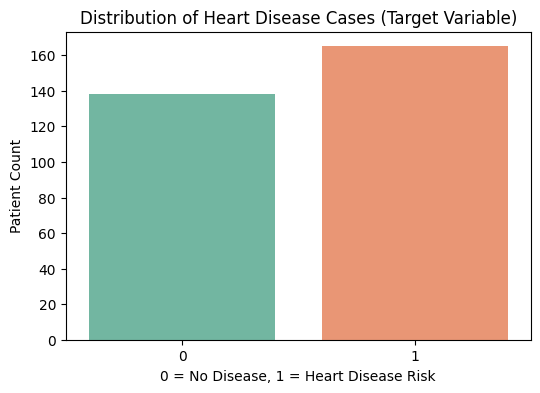

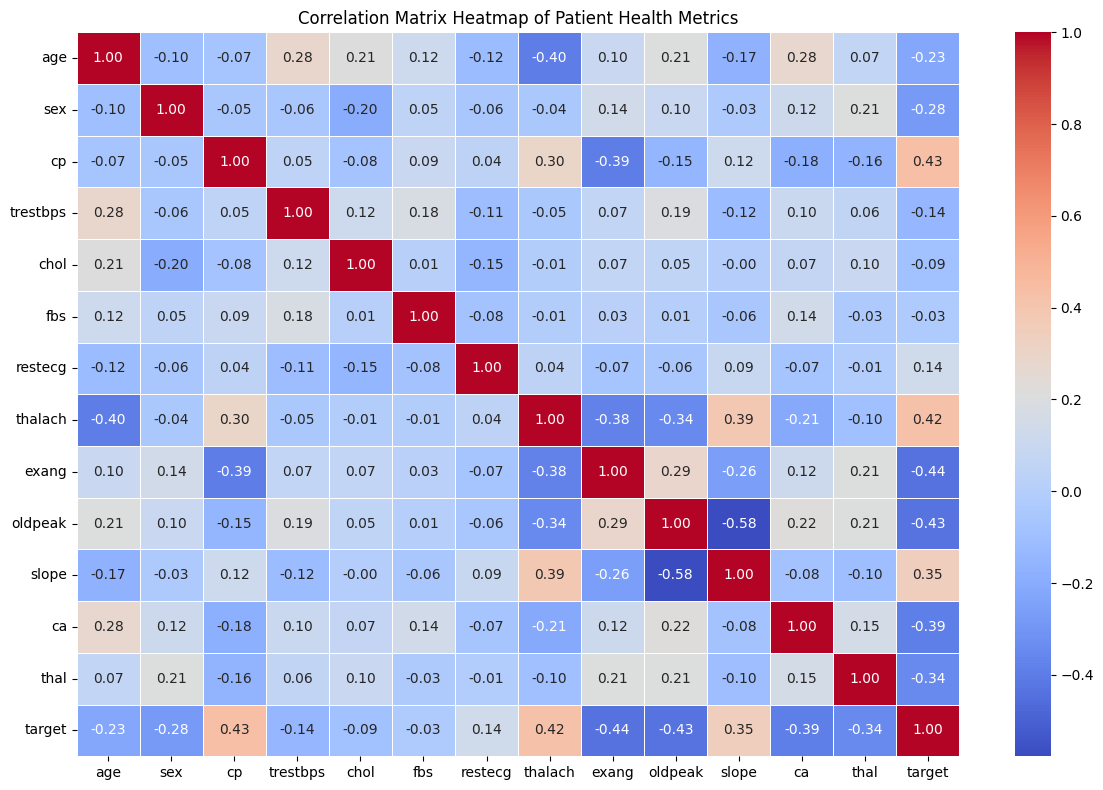

In [4]:
# 1. Visualize the balance of our target classes (0 = Healthy, 1 = Heart Disease Risk)
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Distribution of Heart Disease Cases (Target Variable)")
plt.xlabel("0 = No Disease, 1 = Heart Disease Risk")
plt.ylabel("Patient Count")
plt.show()

# 2. Build a correlation heatmap to find which clinical variables relate strongest to heart risk
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap of Patient Health Metrics")
plt.tight_layout()
plt.show()

In [5]:
# Separate input features (all columns except target) from the prediction output
X = df.drop(columns=['target'])
y = df['target']

# Split data: 80% for training the classifier and 20% for assessing performance
# We use stratify=y to ensure an equal distribution of disease classes in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (242, 13)
Testing features shape: (61, 13)


In [6]:
# Initialize a Logistic Regression classifier (perfect algorithm for binary 0/1 outcomes)
# We scale max_iter up to ensure the mathematical optimizer reaches full convergence
model = LogisticRegression(max_iter=1000)

print("Training the Logistic Regression Classifier...")
model.fit(X_train, y_train)

# Generate predictions and probability scores on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability estimates for the ROC curve
print("Predictions successfully generated!")

Training the Logistic Regression Classifier...
Predictions successfully generated!


c:\Users\Sumbal Khan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Overall Model Accuracy: 80.33%



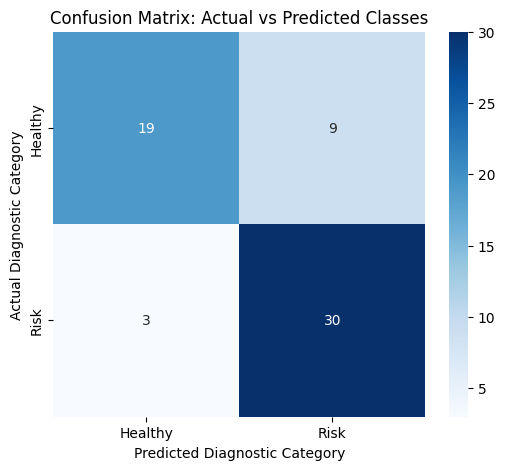

--- Complete Classification Metrics Report ---
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



In [7]:
# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")

# Generate and plot a Confusion Matrix for error checking
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Healthy', 'Risk'], yticklabels=['Healthy', 'Risk'])
plt.title("Confusion Matrix: Actual vs Predicted Classes")
plt.xlabel("Predicted Diagnostic Category")
plt.ylabel("Actual Diagnostic Category")
plt.show()

# Print detailed classification parameters (Precision, Recall, F1-Score)
print("--- Complete Classification Metrics Report ---")
print(classification_report(y_test, y_pred))

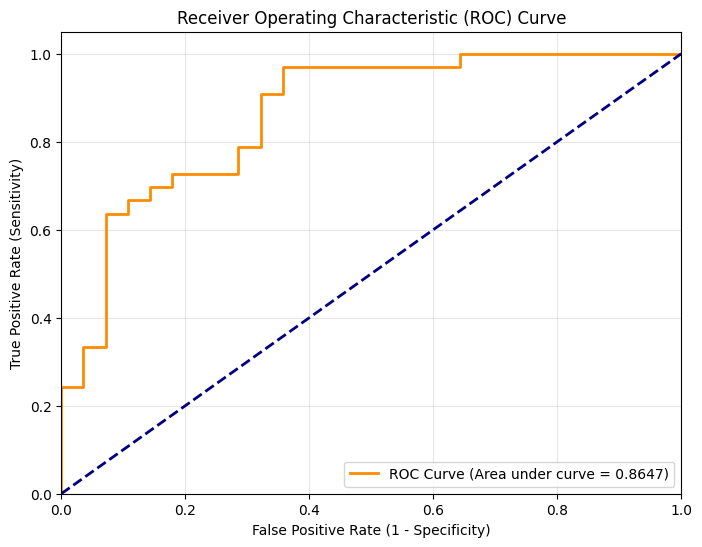

In [8]:
# Compute True Positive Rate and False Positive Rate for our prediction probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve to visually check spatial separation strength
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (Area under curve = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Baseline random chance line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Sumbal Khan\AppData\Local\Temp\ipykernel_24808\3107485916.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance Weight', y='Feature', data=feature_importance_df, palette='vlag')


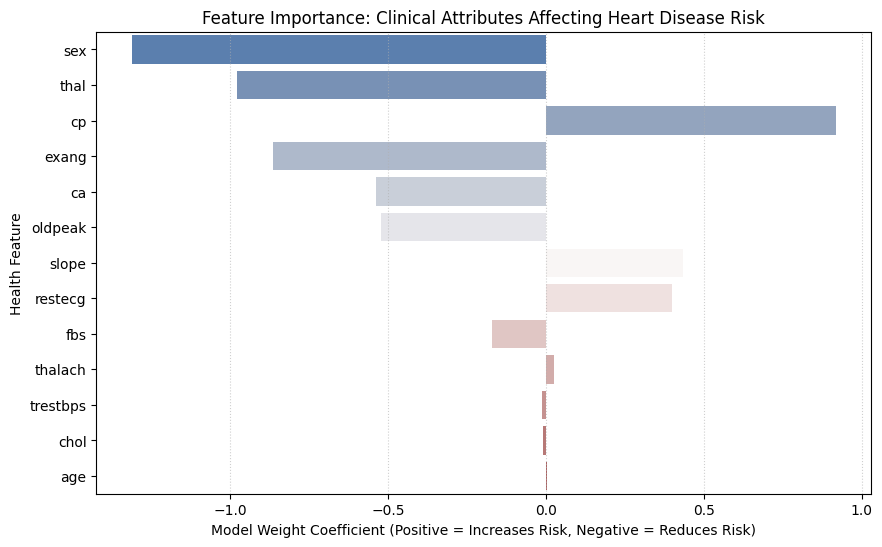

In [9]:
# Extract weights (coefficients) assigned by the model to each clinical indicator
importance = model.coef_[0]

# Organize into a neat DataFrame for plotting
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Weight': importance
})

# Sort features by absolute value size to reveal absolute impact strength
feature_importance_df['Absolute_Importance'] = feature_importance_df['Importance Weight'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Importance', ascending=False)

# Plot feature importance weights
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance Weight', y='Feature', data=feature_importance_df, palette='vlag')
plt.title("Feature Importance: Clinical Attributes Affecting Heart Disease Risk")
plt.xlabel("Model Weight Coefficient (Positive = Increases Risk, Negative = Reduces Risk)")
plt.ylabel("Health Feature")
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()